In [6]:
import pandas as pd
import scanpy as sc
import numpy as np
import collections
import loompy
import infercnvpy as cnv
import cytograph as cg
import cytograph.visualization as cgplot
from cytograph.visualization import Colorizer
from cytograph.visualization.scatter import scatterc, scattern
from cytograph import Algorithm, creates, requires, div0
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from typing import List, Optional
import shoji
import fastcluster
import igraph
import leidenalg as la
import scipy.cluster.hierarchy as hc
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from hmmlearn import hmm
from openTSNE import TSNE
from pynndescent import NNDescent
from tqdm import trange
import warnings
warnings.filterwarnings('ignore')

In [7]:
db = shoji.connect()

In [12]:
#Make sure the top workspace (db.builds.jesper.h5ad) has been made first, created in "Figure_1A_B_C_SupplementaryFigure_S1C_D_E.ipynb"
# Create a subworkspace for holding an example dataset
db.builds.jesper.h5ad.GBM_SL057 = shoji.Workspace()
ws = db.builds.jesper.h5ad.GBM_SL057

In [14]:
#Save h5ad file from url: https://storage.googleapis.com/linnarsson-lab-glioblastoma/woundresponse/SL057.h5ad
#Alternatively follow the instructions at https://github.com/linnarsson-lab/shoji/blob/master/notebooks/GettingStarted_Shoji.ipynb under "Download example dataset" to create a temporary directory for the file.

In [15]:
# Load the sample data into your local Shoji database
ad = sc.read_h5ad('/home/jesper/data/SL057.h5ad')
ws.import_adata(ad, verbose=True)

INFO:root:Loading gene attributes
INFO:root:Loading cells attributes


In [16]:
ad

AnnData object with n_obs × n_vars = 123236 × 59480
    obs: 'CellCycleFraction', 'Celltype', 'Chemistry', 'Clusters', 'ClustersProbability', 'ClustersSecondary', 'ClustersSecondaryProbability', 'DoubletFlag', 'DoubletScore', 'Location', 'ManualAnnotationSL057_MAC', 'ManualAnnotationSL057_Myeloid', 'ManualAnnotationSL057_TAM', 'MitoFraction', 'NGenes', 'NeftelClass', 'Sample', 'SampleID', 'TotalUMIs', 'UnsplicedFraction', 'ValidCells', 'Zone', 'Aneuploid', 'ManualAnnotationSL057'
    var: 'Chromosome', 'End', 'Gene', 'GeneNonzeros', 'GeneTotalUMIs', 'SelectedFeatures', 'Start', 'StdevExpression', 'ValidGenes', 'Accession'
    obsm: 'Embedding', 'Factors', 'NeftelScore'
    layers: 'Expression'

In [17]:
#Change "astype"
Gene = np.array(ad.var.Gene)
ws.Gene = shoji.Tensor(dtype='string', dims=('genes',), inits=Gene.astype('object'))
Exp = ws.Expression[:]
ws.Expression = shoji.Tensor(dtype='uint16', dims=('cells', 'genes'), inits=Exp.astype('uint16'))
Emb = ad.obsm['Embedding']
ws.Embedding = shoji.Tensor(dtype='float32', dims=('cells', 2), inits=Emb.astype('float32'))

# Analyze multi region SL057

## Figure S2

### Colors of choice sampling location (Fig S2A)

In [18]:
Z = ["mediumblue", # Cortex - gray
 "royalblue", #Periphery - blue
 "#B15297", #Low - purple
"deeppink", #High - pink
 "hotpink"] #Necrotic core - black

In [19]:
col = []
FL = ws.Sample[:]
for x in FL:
    if x == 'SL057A':
        col.append(Z[3])
    elif x == 'SL057B':
        col.append(Z[4])
    elif x == 'SL057C':
        col.append(Z[1])
    elif x == 'SL057D':
        col.append(Z[0])

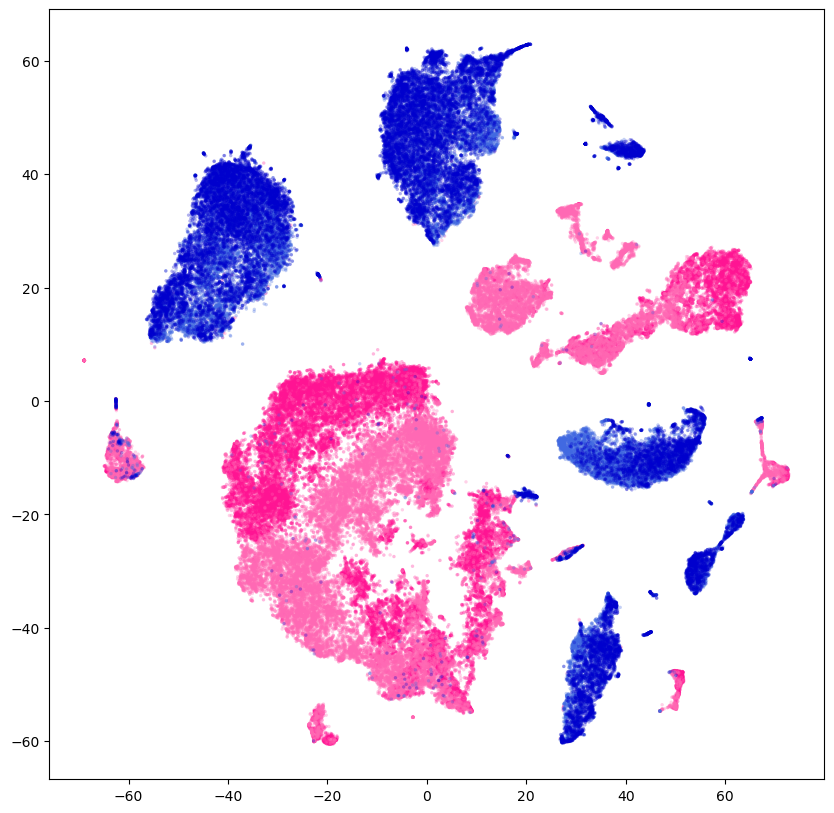

In [20]:
plt.figure(figsize=(10,10))
plt.scatter(ws.Embedding[:, 0], ws.Embedding[:, 1], c=col, s=6, lw=0, alpha=0.3, rasterized=True)
#plt.savefig("/ws/sl/jesper/MES_paper/FigS2/SL057_tSNE_location.pdf", dpi=300, bbox_inches="tight")

### Colors of choice cell types (Fig S2A)

In [21]:
#Cell types
labels2 = [
    'Monocytes',
    'Macrophages',
    'moTAM',
    'mgTAM',
    'Microglia',
    'Oligodendrocytes',
    'Astrocytes',
    'Tumor',
    'Other']

In [22]:
#Colors
Z =["#a580ad",
    "#c7bd80",
[0.99609375, 0.796875, 0.59765625],
 "#b36305", 
"#ee7c0e",
"#000000",
'#4574b3',
 "#74c493",
"#bfbfbf"]

In [23]:
palette_classes = {'Astrocytes':'#4574b3',
 'Doublets': [0.0, 0.45703125, 0.859375],
 'Endothelial': [0.59765625, 0.24609375, 0.0],
 'Fibroblasts': [0.296875, 0.0, 0.359375],
 'Macrophages': "#c7bd80",
 'Microglia': "#ee7c0e",
 'MoTAM': [0.99609375, 0.796875, 0.59765625],
 'MgTAM':  "#b36305",                 
 'Monocytes': "#a580ad",
 'NK, T-cells': [0.578125, 0.99609375, 0.70703125],
 'OPCs': [0.55859375, 0.484375, 0.0],
 'Oligodendrocytes': "#000000",
 'Pericytes': [0.7578125, 0.0, 0.53125],
 'Tumor': "#74c493",
 'VSMC': [0.99609375, 0.640625, 0.01953125]}

In [24]:
Right_order = ['Monocytes','Macrophages','MoTAM','MgTAM','Microglia','Oligodendrocytes','Astrocytes']

In [25]:
col = []
FL = ws.ManualAnnotationSL057_MAC[:]
for x in FL:
    if x == 'Monocytes':
        col.append(Z[0])
    elif x == 'Macrophages':
        col.append(Z[1])
    elif x == 'MoTAM':
        col.append(Z[2])
    elif x == 'MgTAM':
        col.append(Z[3])
    elif x == 'Microglia':
        col.append(Z[4])
    elif x == 'Oligodendrocytes':
        col.append(Z[5])
    elif x == 'Astrocytes':
        col.append(Z[6])
    elif x == 'Tumor':
        col.append(Z[7])
    else:
        col.append(Z[8])

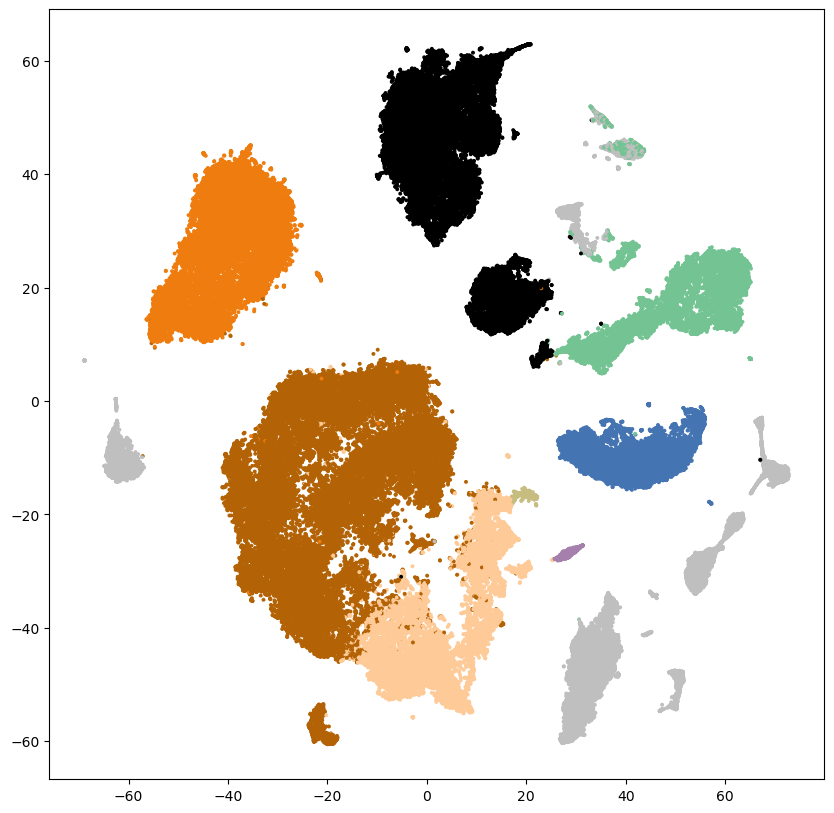

In [26]:
plt.figure(figsize=(10,10))
plt.scatter(ws.Embedding[:, 0], ws.Embedding[:, 1],c=col, s=8, lw=0, rasterized=True)
#plt.savefig("/ws/sl/jesper/MES_paper/FigS2/SL057_tSNE_celltype.pdf", dpi=300, bbox_inches="tight")

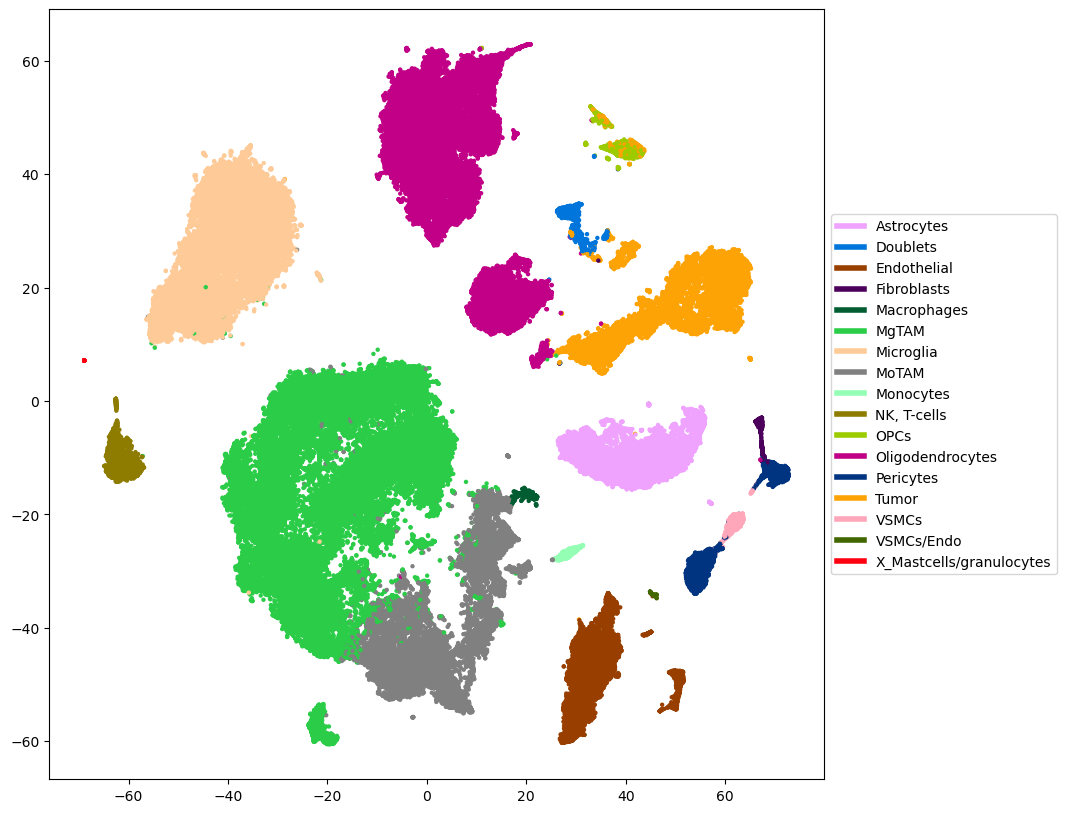

In [27]:
#plot all cell types, (standard colors) not presented in paper 
plt.figure(figsize=(10,10))
cgplot.scatterc(ws.Embedding[:], c=ws.ManualAnnotationSL057_MAC[:], s=10)

### Calc fraction of cell types (Fig S2C)

CPU times: user 6.38 s, sys: 2.27 s, total: 8.65 s
Wall time: 12.1 s


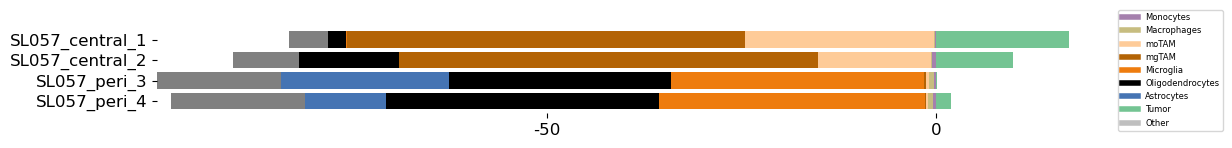

In [28]:
%%time
S = []
Samples = ['SL057A', 'SL057B', 'SL057C', 'SL057D'] #Location/Zones
unique_samples = ['SL057_central_1', 'SL057_central_2', 'SL057_peri_3', 'SL057_peri_4'] #Location/Zones displayed in plot
unique_samples = np.flip(unique_samples)
Samples = np.flip(Samples)
Samples = np.array(Samples, dtype=object)
unique_samples = np.array(unique_samples, dtype=object)
labels = np.unique(ws.ManualAnnotationSL057_MAC[:]) # all unique cell types
for i, sample in enumerate(Samples):
    Man = ws.ManualAnnotationSL057_MAC[:][ws.Sample[:] == sample] #All cells in location
    Sum = []
    for x in labels:
        Sum.append(np.sum(np.isin(Man, x))) #loop through all cell types and count total
    Percent = []
    tot = np.sum(Sum) #total number cells
    for x in Sum: #calc percentage of total for all cell types
        roundedNumber = round(x/tot * 100, 3) #round and multiply by 100 in order to show percentage
        Perc = str(roundedNumber) + "%"
        Percent.append(roundedNumber)
    size = np.array(Percent)
    S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
#All non-malignant cell types except "other"
nontumor_bars = df.drop(['Doublets','Endothelial','Fibroblasts','NK, T-cells','OPCs','Pericytes','VSMCs', 'VSMCs/Endo','X_Mastcells/granulocytes','Tumor'], axis=1)
other_bars = df[['Doublets','Endothelial','Fibroblasts','NK, T-cells','OPCs','Pericytes','VSMCs', 'VSMCs/Endo','X_Mastcells/granulocytes']] #other
tumor_bars = df[["Tumor"]] #tumor cells
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(10, 1.15))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([-50,0,50])
ax1.xaxis.set_visible(True) 
ax1.set_xticklabels([-50,0,50],fontsize=12)
#Plot percentage of different cell types (bars horizontal)
for i, ct in enumerate(Right_order):
    ax1.barh(unique_samples,height=0.8, width=-nontumor_bars[ct],left=-left, color=palette_classes[ct])
    left += nontumor_bars[ct]
for i, ct in enumerate(other_bars):
    ax1.barh(unique_samples,height=0.8, width=-other_bars[ct],left=-left, color=[0.5, 0.5, 0.5])
    left += other_bars[ct]
for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=palette_classes[ct])
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in Z]
ax1.legend(hidden_lines,labels2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12)
None
#plt.savefig("/ws/sl/jesper/MES_paper/FigS2/SL057_celltypes_zones_barplot.pdf",dpi=300, bbox_inches="tight")

### Calc Neftel-substates for all cells and plot tSNE (Fig S2C)

In [53]:
%%time
cg.NeftelStates().fit(ws, save=True)

INFO:root:Loading genes
INFO:root:Loading expression matrix
INFO:root:Normalizing to median total UMI
INFO:root:Calculating relative expression
INFO:root:Ordering genes by absolute expression
INFO:root:Computing signature scores
INFO:root: [Creating tensor NeftelClass of shape (123236,)]
INFO:root: [Creating tensor NeftelScore of shape (123236, 4)]


CPU times: user 4min 41s, sys: 7min 9s, total: 11min 50s
Wall time: 12min 53s


(array([[-2.52376745,  5.34370925, -0.39997334, -1.43125786],
        [-4.08602159,  2.6532884 , -0.50934261, -2.04126603],
        [-3.4869815 , -1.15107964, -0.12348165, -1.59854531],
        ...,
        [17.52960159,  2.03178389,  0.06376053,  0.75294995],
        [-2.72916428, -4.71221784,  0.6005042 ,  4.6537955 ],
        [18.2739028 , -2.2392457 ,  0.15423587,  0.7365907 ]]),
 array(['MES', 'MES', 'NPC', ..., 'AC', 'OPC', 'AC'], dtype='<U3'))

In [29]:
#If cytograph takes too much time or does not work, you can transfer scores that have already been saved on the h5ad-files
NS = ad.obsm['NeftelScore'] 
ws.NeftelScore = shoji.Tensor(dtype='float32', dims=('cells', 4), inits=NS.astype('float32'))

CPU times: user 6.48 s, sys: 2.26 s, total: 8.75 s
Wall time: 12.5 s


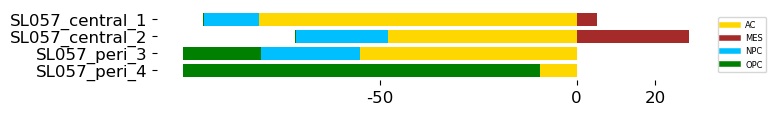

In [30]:
%%time
S = []
Samples = ['SL057A', 'SL057B', 'SL057C', 'SL057D'] #Location/Zones
unique_samples = ['SL057_central_1', 'SL057_central_2', 'SL057_peri_3', 'SL057_peri_4'] #Location/Zones as displayed in plot
Samples = np.array(Samples, dtype=object)
Samples = np.flip(Samples)
unique_samples = np.array(unique_samples, dtype=object)
unique_samples = np.flip(unique_samples)
A = ['AC', 'MES', 'NPC', 'OPC'] # Neftel substates
labels = np.array(A, dtype=object)
for i, sample in enumerate(Samples):
    ac, mes, npc, opc = np.hsplit(ws.NeftelScore[ws.Sample[:] == sample][ws.ManualAnnotationSL057[ws.Sample[:] == sample] == 'Tumor'], 4)
    winnersAll = np.argmax([ac, mes, npc, opc], axis=0) #The subtype with the highest score of the four is assigned to the cell
    Man = np.hstack(labels[winnersAll])
    Sum = []
    for x in labels: #loop through all states and count total
        Sum.append(np.sum(np.isin(Man, x)))
    Percent = []
    tot = np.sum(Sum) #total number tumor cells
    for x in Sum: #calc percentage of total for all states
        roundedNumber = round(x/tot * 100, 3)
        Perc = str(roundedNumber) + "%"
        Percent.append(roundedNumber)
    size = np.array(Percent)
    S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
nontumor_bars = df.drop('MES', axis=1)
tumor_bars = df[["MES"]] # show MES-fraction separately
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(6, len(Samples)*0.25))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([-50,0,20])
ax1.xaxis.set_visible(True) 
ax1.set_xticklabels([-50,0,20],fontsize=12)
colors=["gold", "brown", "deepskyblue", "green"]
pcolors = dict(zip(labels, colors))

for i, ct in enumerate(nontumor_bars):
    ax1.barh(unique_samples,height=0.8, width=-nontumor_bars[ct],left=-left, color=pcolors[ct])
    left += nontumor_bars[ct]
for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=pcolors[ct])
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in colors]
ax1.legend(hidden_lines,labels, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12)
None
#plt.savefig("/ws/sl/jesper/MES_paper/FigS2/SL057_cellstates_zones_barplot.pdf",dpi=300, bbox_inches="tight")

In [31]:
#Cell types displayed with colormaps
celltype = ['Tumor', 'TAM', 'Oligodendrocytes']

### Full list of MES1 and MES2 genes

In [32]:
MES1 = np.array(["CHI3L1","ANXA2","ANXA1","CD44","VIM","MT2A","C1S","NAMPT","EFEMP1","C1R","SOD2","IFITM3","TIMP1","SPP1","A2M","S100A11","MT1X","S100A10","FN1","LGALS1","S100A16","CLIC1","MGST1","RCAN1","TAGLN2","NPC2","SERPING1","TCIM","EMP1","APOE","CTSB","C3","LGALS3","MT1E","EMP3","SERPINA3","ACTN1","PRDX6","IGFBP7","SERPINE1","PLP2","MGP","CLIC4","GFPT2","GSN","NNMT","TUBA1C","GJA1","TNFRSF1A","WWTR1"])
MES2 = np.array(["HILPDA","ADM","DDIT3","NDRG1","HERPUD1","DNAJB9","TRIB3","ENO2","AKAP12","SQSTM1","MT1X","ATF3","NAMPT","NRN1","SLC2A1","BNIP3","LGALS3","INSIG2","IGFBP3","PPP1R15A","VIM","PLOD2","GBE1","SLC2A3","FTL","WARS1","ERO1A","XPOT","HSPA5","GDF15","ANXA2","EPAS1","LDHA","P4HA1","SERTAD1","PFKP","PGK1","EGLN3","SLC6A6","CA9","BNIP3L","RPL21","TRAM1","UFM1","ASNS","GOLT1B","ANGPTL4","SLC39A14","CDKN1A","HSPA9"])
gene_list = np.concatenate((MES1, MES2))
_, i = np.unique(gene_list, return_index=True)
gene_list = gene_list[np.sort(i)]
gene_list

array(['CHI3L1', 'ANXA2', 'ANXA1', 'CD44', 'VIM', 'MT2A', 'C1S', 'NAMPT',
       'EFEMP1', 'C1R', 'SOD2', 'IFITM3', 'TIMP1', 'SPP1', 'A2M',
       'S100A11', 'MT1X', 'S100A10', 'FN1', 'LGALS1', 'S100A16', 'CLIC1',
       'MGST1', 'RCAN1', 'TAGLN2', 'NPC2', 'SERPING1', 'TCIM', 'EMP1',
       'APOE', 'CTSB', 'C3', 'LGALS3', 'MT1E', 'EMP3', 'SERPINA3',
       'ACTN1', 'PRDX6', 'IGFBP7', 'SERPINE1', 'PLP2', 'MGP', 'CLIC4',
       'GFPT2', 'GSN', 'NNMT', 'TUBA1C', 'GJA1', 'TNFRSF1A', 'WWTR1',
       'HILPDA', 'ADM', 'DDIT3', 'NDRG1', 'HERPUD1', 'DNAJB9', 'TRIB3',
       'ENO2', 'AKAP12', 'SQSTM1', 'ATF3', 'NRN1', 'SLC2A1', 'BNIP3',
       'INSIG2', 'IGFBP3', 'PPP1R15A', 'PLOD2', 'GBE1', 'SLC2A3', 'FTL',
       'WARS1', 'ERO1A', 'XPOT', 'HSPA5', 'GDF15', 'EPAS1', 'LDHA',
       'P4HA1', 'SERTAD1', 'PFKP', 'PGK1', 'EGLN3', 'SLC6A6', 'CA9',
       'BNIP3L', 'RPL21', 'TRAM1', 'UFM1', 'ASNS', 'GOLT1B', 'ANGPTL4',
       'SLC39A14', 'CDKN1A', 'HSPA9'], dtype='<U8')

### Colormap for relevant cell types across all MES-genes and zones (Fig S2D)

CPU times: user 34min 1s, sys: 11min 31s, total: 45min 32s
Wall time: 1h 4min 55s


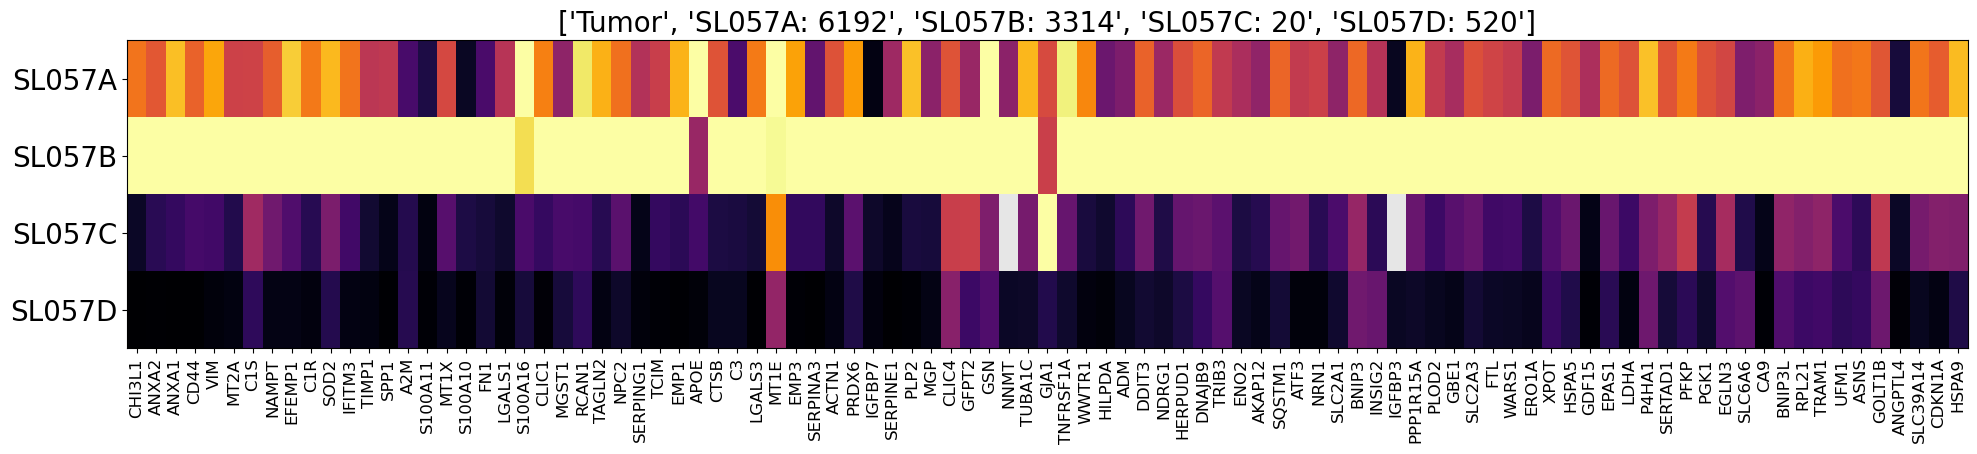

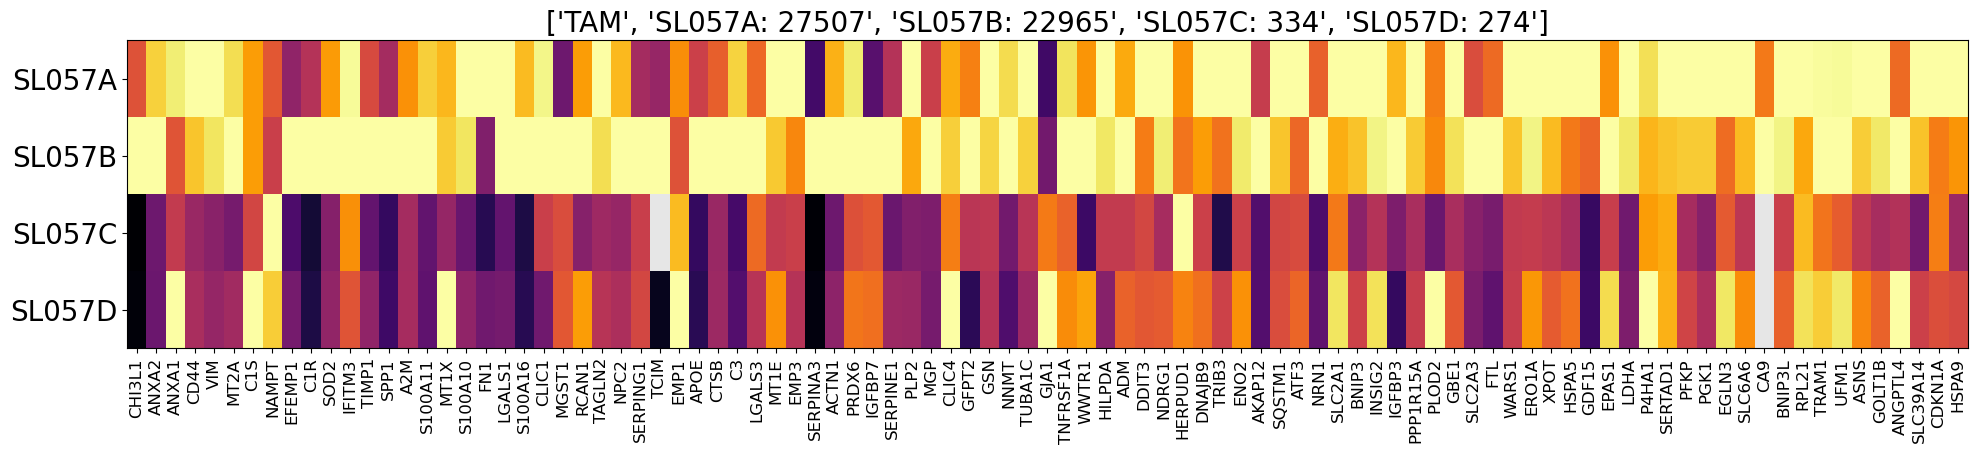

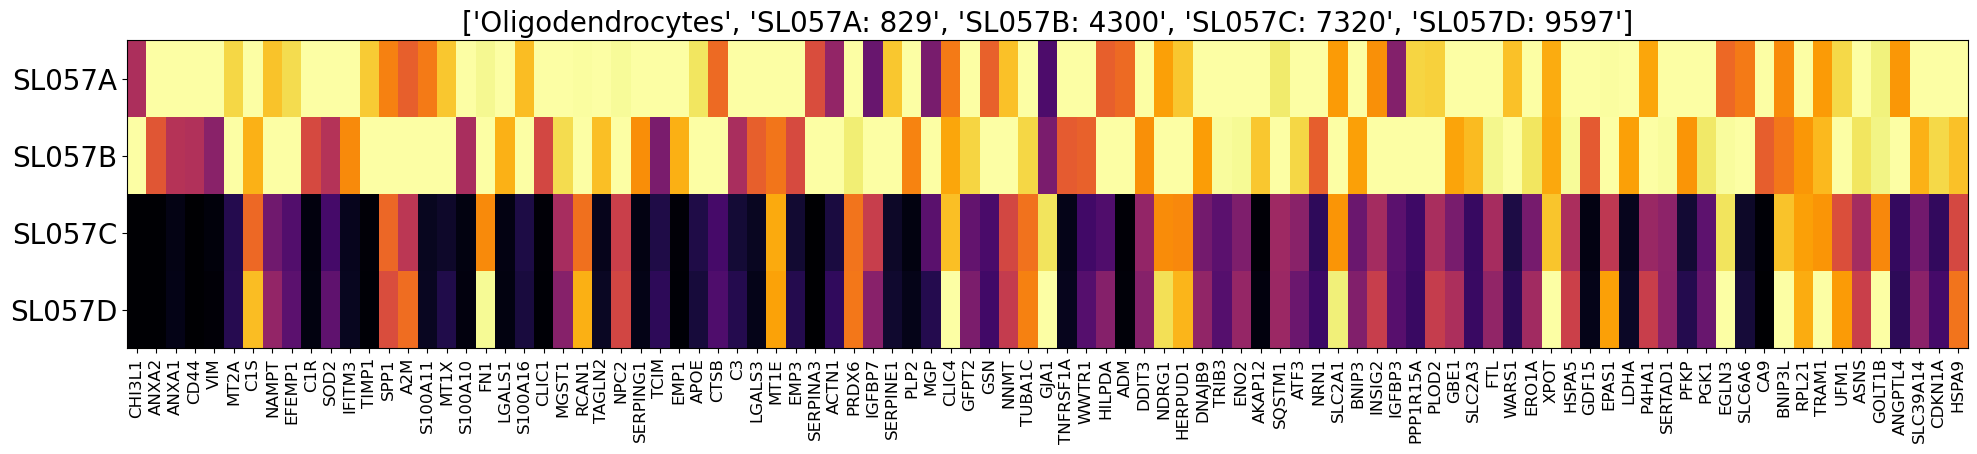

In [33]:
%%time
#Colormap for all cell types, normalized internally. Print number of cells per location on top
Samples = ['SL057A', 'SL057B', 'SL057C', 'SL057D']
Samples = np.array(Samples, dtype=object)
for cell in celltype:
    Sum = [cell]
    unique_samples = []
    for i, sample in enumerate(Samples):
        Su = np.sum(ws.ManualAnnotationSL057_TAM[ws.Sample[:] == sample] == cell)
        Sum.append(sample + ": " + str(Su))
        if Su > 0:
            unique_samples.append(sample)
    n_genes = len(gene_list)
    n_clusters = len(unique_samples)
    x = np.zeros((n_genes, n_clusters))
    for i, gene in enumerate(gene_list): #check mean expression of every gene in cell type and zone
        gene_ix = np.where(ws.Gene[:] == gene)[0][0]
        for n, sample in enumerate(unique_samples):
            x[i, n] = np.mean(ws.Expression[:, ws.Gene == str(gene)][ws.Sample[:] == sample][ws.ManualAnnotationSL057_TAM[ws.Sample[:] == sample] == cell])

    # Normalize
    totals = x.sum(axis=1)
    xY = (x.T / totals * np.median(totals)).T
    xY = cg.div0(xY.T, np.percentile(xY, 99.5, axis=1)).T

    # Make background grey for zeros
    xY = xY.T
    G = xY
    bg = np.zeros_like(xY) + 0.9
    xY = np.ma.masked_where(xY == 0, xY)
    plt.figure(None, (n_genes / 4, 4))
    plt.imshow(bg[:], vmin=0, vmax=1, cmap=plt.cm.gray, aspect="auto")
    plt.imshow(xY[:], cmap="inferno", vmin=0, vmax=1, interpolation= "nearest", aspect="auto", alpha=1)
    plt.xticks(ticks=range(n_genes),labels=gene_list, fontsize=12, rotation=90)
    plt.yticks(ticks=range(n_clusters), labels=unique_samples, fontsize=20)
    plt.title(list(Sum),fontsize=20)
    None
    #plt.savefig("/ws/sl/jesper/MES_paper/FigS2/SL057_Heatmap_MES_normalized" + cell + ".pdf",dpi=300, bbox_inches="tight")

### Prep data Fig S2E

In [34]:
# Create a subworkspace for holding an example dataset
db.builds.jesper.h5ad.KS920_924_925 = shoji.Workspace()
ws = db.builds.jesper.h5ad.KS920_924_925

In [35]:
#Save h5ad file from url: https://storage.googleapis.com/linnarsson-lab-glioblastoma/woundresponse/KS920_924_925.h5ad
#Alternatively follow the instructions at https://github.com/linnarsson-lab/shoji/blob/master/notebooks/GettingStarted_Shoji.ipynb under "Download example dataset" to create a temporary directory for the file.

In [36]:
# Load the sample data (https://storage.googleapis.com/linnarsson-lab-glioblastoma/woundresponse/KS920_924_925.h5ad) into your local Shoji database
ad = sc.read_h5ad('/home/jesper/data/KS920_924_925.h5ad')
ws.import_adata(ad, verbose=True)

INFO:root:Loading gene attributes
INFO:root:Loading cells attributes


In [37]:
Gene = np.array(ad.var.Gene)
ws.Gene = shoji.Tensor(dtype='string', dims=('genes',), inits=Gene.astype('object'))
Exp = ws.Expression[:]
ws.Expression = shoji.Tensor(dtype='uint16', dims=('cells', 'genes'), inits=Exp.astype('uint16'))

### Calc Neftel-substates for all cells and plot tSNE (Fig S2E)

In [ ]:
cg.NeftelStates().fit(ws, save=True)

INFO:root:Loading genes
INFO:root:Loading expression matrix
INFO:root:Normalizing to median total UMI
INFO:root:Calculating relative expression
INFO:root:Ordering genes by absolute expression
INFO:root:Computing signature scores
INFO:root: [Creating tensor NeftelClass of shape (25468,)]
INFO:root: [Creating tensor NeftelScore of shape (25468, 4)]


(array([[-0.78591135, -4.86790945,  0.46690871,  6.09562909],
        [-3.0620806 , -2.44029957, -0.8673124 , -3.57335743],
        [ 1.10776405, -4.59210762,  0.87202818,  7.39330509],
        ...,
        [-2.4251781 ,  5.29036266, -1.2191506 , -3.39130728],
        [-2.56565696, -0.85946533, -1.2115489 , -4.01599646],
        [-1.74287065, -5.0510143 ,  0.49757508,  5.57305515]]),
 array(['OPC', 'NPC', 'OPC', ..., 'MES', 'MES', 'OPC'], dtype='<U3'))

In [38]:
#If cytograph takes too much time or does not work, you can transfer scores that have already been saved on the h5ad-files
NS = ad.obsm['NeftelScore'] 
ws.NeftelScore = shoji.Tensor(dtype='float32', dims=('cells', 4), inits=NS.astype('float32'))

### Colors of choice cell types

In [39]:
Right_order = ['Monocytes','MoTAM','MgTAM','Microglia','Oligodendrocytes','Astrocytes']
palette_classes = {'Astrocytes': '#4574b3',
 'Endothelial': [0.59765625, 0.24609375, 0.0],
 'Fibroblasts': [0.296875, 0.0, 0.359375],
 'Microglia': "#ee7c0e",
 'MoTAM': [0.99609375, 0.796875, 0.59765625], 
 'MgTAM': "#b36305",   
 'Monocytes': "#a580ad",
 'Mural': [0.7578125, 0.0, 0.53125],
 'NK, T-cells': [0.578125, 0.99609375, 0.70703125],
 'OPCs': [0.55859375, 0.484375, 0.0],
 'Oligodendrocytes': "#000000",
 'Tumor': "#74c493"}

In [40]:
Z =["#a580ad",
[0.99609375, 0.796875, 0.59765625],
 "#b36305", 
"#ee7c0e",
"#000000",
'#4574b3',
 "#74c493",
"#bfbfbf"]

In [41]:
labels2 = [
    'Monocytes',
    'moTAM',
    'mgTAM',
    'Microglia',
    'Oligodendrocytes',
    'Astrocytes',
    'Tumor',
    'Other']

### Calc fraction of cell types (Fig S2E)

CPU times: user 1.07 s, sys: 363 ms, total: 1.43 s
Wall time: 1.92 s


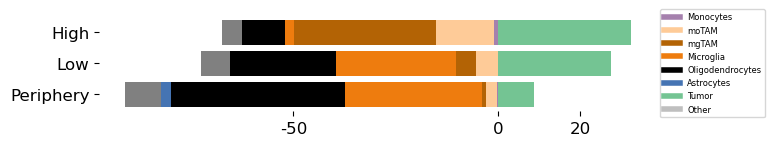

In [42]:
%%time
S = []
Samples = ['High', 'Low', 'Periphery']
Samples = np.array(Samples, dtype=object)
Samples = np.flip(Samples)
unique_samples = Samples
Samples = np.array(Samples, dtype=object)
labels = np.unique(ws.Annotation_all[:])
for i, sample in enumerate(Samples):
    Man = ws.Annotation_all[:][ws.Zone[:] == sample]
    Sum = []
    for x in labels:
        Sum.append(np.sum(np.isin(Man, x)))
    Percent = []
    tot = np.sum(Sum)
    for x in Sum:
        roundedNumber = round(x/tot * 100, 1)
        Perc = str(roundedNumber) + "%"
        Percent.append(roundedNumber)
    size = np.array(Percent)
    S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
nontumor_bars = df.drop(['Endothelial', 'Fibroblasts','Mural','NK, T-cells', 'OPCs','Tumor'], axis=1)
other_bars = df[['Endothelial', 'Fibroblasts','Mural','NK, T-cells', 'OPCs']]
other_bars['Sum'] = other_bars.sum(axis=1)
other_bars.drop(['Endothelial', 'Fibroblasts','Mural','NK, T-cells', 'OPCs'], axis=1, inplace=True)
tumor_bars = df[["Tumor"]]

left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(6, 1.25))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([-50,0,20])
ax1.xaxis.set_visible(True) 

ax1.set_xticklabels([-50,0,20],fontsize=12)

for i, ct in enumerate(Right_order):
    ax1.barh(unique_samples,height=0.8, width=-nontumor_bars[ct],left=-left, color=palette_classes[ct])
    left += nontumor_bars[ct]
for i, ct in enumerate(other_bars):
    ax1.barh(unique_samples,height=0.8, width=-other_bars[ct],left=-left, color=[0.5, 0.5, 0.5])
    left += other_bars[ct]
for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=palette_classes[ct])
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in Z]
ax1.legend(hidden_lines,labels2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12)
None
#plt.savefig("/ws/sl/jesper/MES_paper/SupplFig2/E_KS920_924_925_celltypes_zones_barplot.pdf",dpi=300, bbox_inches="tight")

### Tumor cells, MES fraction sample KS920 (Fig S2E)

CPU times: user 4.33 s, sys: 1.48 s, total: 5.81 s
Wall time: 8.69 s


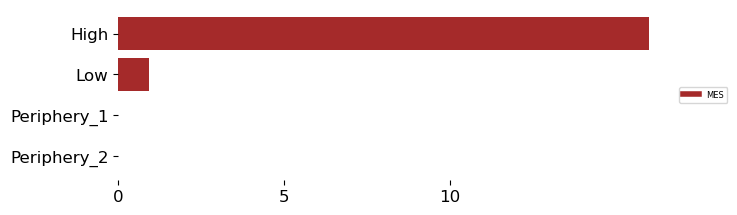

In [43]:
%%time
S = []
Samples = ['High', 'Low','Periphery_1', 'Periphery_2'] #Locations sampled
Samples = np.array(Samples, dtype=object)
Samples = np.flip(Samples)
unique_samples = []
Samples = np.array(Samples, dtype=object)
A = ['AC', 'MES', 'NPC', 'OPC']
labels = np.array(A, dtype=object)
for i, sample in enumerate(Samples):
            Su = np.sum(ws.Sample[ws.Location[:] == sample][ws.Annotation_all[ws.Location[:] == sample] == 'Tumor'] == 'KS920')
            if Su > 0:
                unique_samples.append(sample)
                ac, mes, npc, opc = np.hsplit(ws.NeftelScore[ws.Location[:] == sample][ws.Annotation_all[ws.Location[:] == sample] == 'Tumor'][ws.Sample[ws.Location[:] == sample][ws.Annotation_all[ws.Location[:] == sample] == 'Tumor'] == 'KS920'], 4)
                winnersAll = np.argmax([ac, mes, npc, opc], axis=0)
                Man = np.hstack(labels[winnersAll])
                Sum = []
                for x in labels:
                    Sum.append(np.sum(np.isin(Man, x)))
                Percent = []
                tot = np.sum(Sum)
                for x in Sum:
                    roundedNumber = round(x/tot * 100, 3)
                    Perc = str(roundedNumber) + "%"
                    Percent.append(roundedNumber)
                size = np.array(Percent)
                S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
tumor_bars = df[["MES"]] #MES fraction separately
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(6, len(unique_samples)*0.5))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([0,5,10,20])
ax1.xaxis.set_visible(True) 
ax1.set_xticklabels([0,5,10,20],fontsize=12)
colors=["brown"]
labels = ['MES']
labels = np.array(labels, dtype=object)
pcolors = dict(zip(labels, colors))

for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=pcolors[ct]) #only plot MES-fraction
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in colors]
ax1.legend(hidden_lines,labels, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12)
None
#plt.savefig("/ws/sl/jesper/MES_paper/FigS2/E_KS920_MES_zones_barplot.pdf",dpi=300, bbox_inches="tight")

### Tumor cells, MES fraction sample KS924 (Fig S2E)

CPU times: user 2.28 s, sys: 814 ms, total: 3.1 s
Wall time: 4.38 s


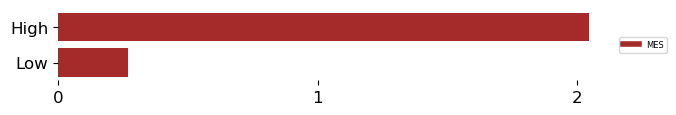

In [44]:
%%time
S = []
Samples = ['High', 'Low'] #Locations sampled
Samples = np.array(Samples, dtype=object)
Samples = np.flip(Samples)
unique_samples = []
Samples = np.array(Samples, dtype=object)
A = ['AC', 'MES', 'NPC', 'OPC']
labels = np.array(A, dtype=object)
for i, sample in enumerate(Samples):
            Su = np.sum(ws.Sample[ws.Location[:] == sample][ws.Annotation_all[ws.Location[:] == sample] == 'Tumor'] == 'KS924')
            if Su > 0:
                unique_samples.append(sample)
                ac, mes, npc, opc = np.hsplit(ws.NeftelScore[ws.Location[:] == sample][ws.Annotation_all[ws.Location[:] == sample] == 'Tumor'][ws.Sample[ws.Location[:] == sample][ws.Annotation_all[ws.Location[:] == sample] == 'Tumor'] == 'KS924'], 4)
                winnersAll = np.argmax([ac, mes, npc, opc], axis=0)
                Man = np.hstack(labels[winnersAll])
                Sum = []
                for x in labels:
                    Sum.append(np.sum(np.isin(Man, x)))
                Percent = []
                tot = np.sum(Sum)
                for x in Sum:
                    roundedNumber = round(x/tot * 100, 3)
                    Perc = str(roundedNumber) + "%"
                    Percent.append(roundedNumber)
                size = np.array(Percent)
                S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
tumor_bars = df[["MES"]]
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(6, len(unique_samples)*0.5))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([0,1,2])
ax1.xaxis.set_visible(True) 
ax1.set_xticklabels([0,1,2],fontsize=12)
colors=["brown"]
labels = ['MES']
labels = np.array(labels, dtype=object)
pcolors = dict(zip(labels, colors))

for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=pcolors[ct]) #only plot MES-fraction
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in colors]
ax1.legend(hidden_lines,labels, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12)
None
#plt.savefig("/ws/sl/jesper/MES_paper/FigS2/E_KS924_MES_zones_barplot.pdf",dpi=300, bbox_inches="tight")

### Tumor cells, MES fraction sample KS925 (Fig S2E)

CPU times: user 3.21 s, sys: 1.15 s, total: 4.36 s
Wall time: 6.16 s


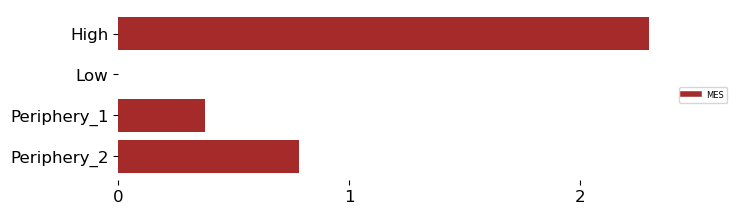

In [45]:
%%time
S = []
Samples = ['High','Periphery_1', 'Periphery_2'] #Locations sampled
Samples = np.array(Samples, dtype=object)
Samples = np.flip(Samples)
unique_samples = []
Samples = np.array(Samples, dtype=object)
A = ['AC', 'MES', 'NPC', 'OPC']
labels = np.array(A, dtype=object)
for i, sample in enumerate(Samples):
            Su = np.sum(ws.Sample[ws.Location[:] == sample][ws.Annotation_all[ws.Location[:] == sample] == 'Tumor'] == 'KS925')
            if Su > 0:
                unique_samples.append(sample)
                ac, mes, npc, opc = np.hsplit(ws.NeftelScore[ws.Location[:] == sample][ws.Annotation_all[ws.Location[:] == sample] == 'Tumor'][ws.Sample[ws.Location[:] == sample][ws.Annotation_all[ws.Location[:] == sample] == 'Tumor'] == 'KS925'], 4)
                winnersAll = np.argmax([ac, mes, npc, opc], axis=0)
                Man = np.hstack(labels[winnersAll])
                Sum = []
                for x in labels:
                    Sum.append(np.sum(np.isin(Man, x)))
                Percent = []
                tot = np.sum(Sum)
                for x in Sum:
                    roundedNumber = round(x/tot * 100, 3)
                    Perc = str(roundedNumber) + "%"
                    Percent.append(roundedNumber)
                size = np.array(Percent)
                S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
tumor_bars = df[["MES"]] #MES fraction only
left = np.zeros(len(unique_samples))
unique_samples = ['Periphery_2', 'Periphery_1', 'Low', 'High']
fig, ax1 = plt.subplots(figsize=(6, len(unique_samples)*0.5))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([0,1,2])
ax1.xaxis.set_visible(True) 
ax1.set_xticklabels([0,1,2],fontsize=12)
colors=["brown"]
labels = ['MES']
labels = np.array(labels, dtype=object)
pcolors = dict(zip(labels, colors))


tumor_bars.loc['Low'] = [0] #Add to figure, not sampled!
tumor_bars = tumor_bars.reindex(['Periphery_2','Periphery_1','Low','High'])
tumor_bars
for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=pcolors[ct]) #only plot MES-fraction
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in colors]
ax1.legend(hidden_lines,labels, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12)
None
#plt.savefig("/ws/sl/jesper/MES_paper/FigS2/E_KS925_MES_zones_barplot.pdf",dpi=300, bbox_inches="tight")

## Heatmap of the inferred CNV profile SL057 (Not presented)

In [46]:
# Load the sample data into your local Shoji database
ad = sc.read_h5ad('/home/jesper/data/SL057.h5ad')

In [47]:
ad.var_names_make_unique()

In [48]:
ad

AnnData object with n_obs × n_vars = 123236 × 59480
    obs: 'CellCycleFraction', 'Celltype', 'Chemistry', 'Clusters', 'ClustersProbability', 'ClustersSecondary', 'ClustersSecondaryProbability', 'DoubletFlag', 'DoubletScore', 'Location', 'ManualAnnotationSL057_MAC', 'ManualAnnotationSL057_Myeloid', 'ManualAnnotationSL057_TAM', 'MitoFraction', 'NGenes', 'NeftelClass', 'Sample', 'SampleID', 'TotalUMIs', 'UnsplicedFraction', 'ValidCells', 'Zone', 'Aneuploid', 'ManualAnnotationSL057'
    var: 'Chromosome', 'End', 'Gene', 'GeneNonzeros', 'GeneTotalUMIs', 'SelectedFeatures', 'Start', 'StdevExpression', 'ValidGenes', 'Accession'
    obsm: 'Embedding', 'Factors', 'NeftelScore'
    layers: 'Expression'

In [49]:
ad.var["chromosome"] = ad.var["Chromosome"]
ad.var["start"] = ad.var["Start"]
ad.var["end"] = ad.var["End"]
ad.var["ensg"] = ad.var["Accession"]

In [50]:
#Normalize and logaritmize
sc.pp.normalize_total(ad)
sc.pp.log1p(ad)

In [51]:
cnv.tl.infercnv(ad, window_size=500, exclude_chromosomes=('', 'GL000009.2', 'GL000194.1', 'GL000195.1', 'GL000205.2',
       'GL000213.1', 'GL000216.2', 'GL000218.1', 'GL000219.1',
       'GL000220.1', 'GL000225.1', 'KI270442.1', 'KI270711.1',
       'KI270713.1', 'KI270721.1', 'KI270726.1', 'KI270727.1',
       'KI270728.1', 'KI270731.1', 'KI270733.1', 'KI270734.1',
       'KI270744.1', 'KI270750.1','chrM','chrY'), reference_key="ManualAnnotationSL057",reference_cat=["Astrocytes", "Microglia","MgTAM", "Oligodendrocytes", "Endothelial"])

  0%|          | 0/25 [00:00<?, ?it/s]

{'heatmap_ax': <Axes: >,
 'groupby_ax': <Axes: ylabel='Aneuploid'>,
 'gene_groups_ax': <Axes: >}

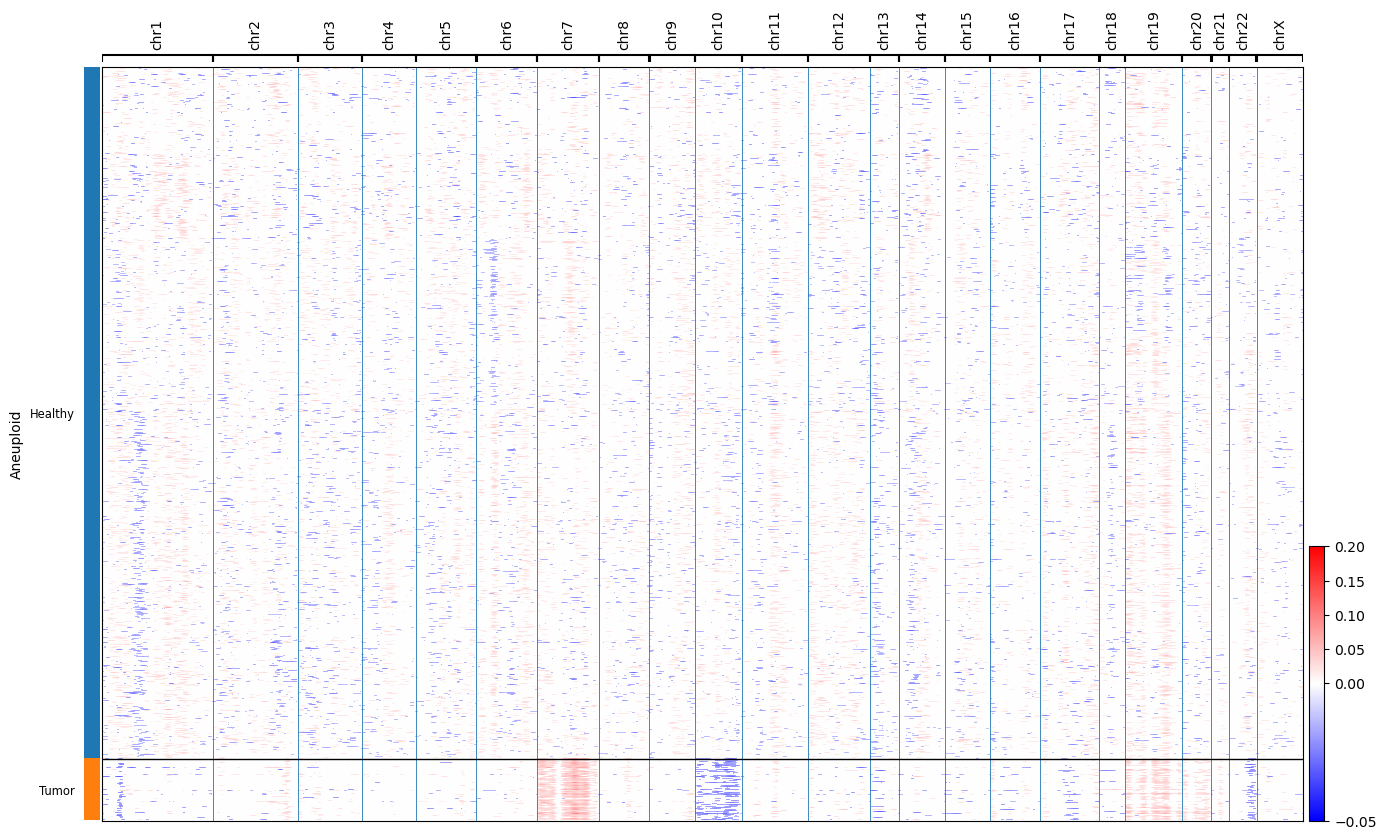

In [52]:
cnv.pl.chromosome_heatmap(ad, groupby="Aneuploid", show=False, cmap='bwr',vmin = -0.05, vmax = 0.2)